In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
df =pd.read_csv("lending_club_loan_two.csv")

In [4]:
meta_data= pd.read_csv("lending_club_info.csv")

In [5]:
meta_data.head(5)

,LoanStatNew,Description
0,loan_amnt,The listed amount of the loan applied for by t...
1,term,The number of payments on the loan. Values are...
2,int_rate,Interest Rate on the loan
3,installment,The monthly payment owed by the borrower if th...
4,grade,LC assigned loan grade


In [6]:
df.shape

(396030, 27)

<Axes: xlabel='loan_status', ylabel='count'>

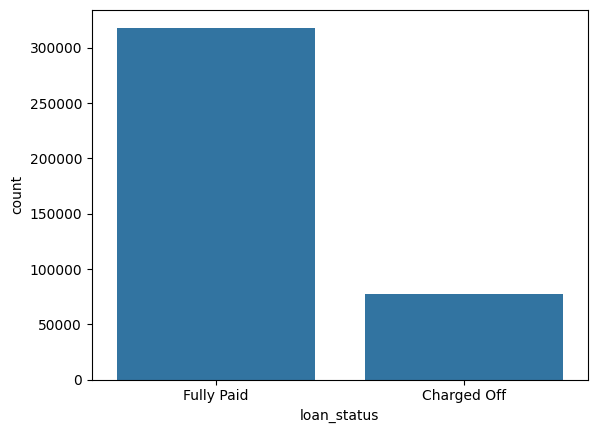

In [7]:
sns.countplot(x='loan_status', data=df)

In [8]:
df["loan_status"].value_counts()*100/len(df)

,count
loan_status,
Fully Paid,80.387092
Charged Off,19.612908


<Axes: xlabel='loan_amnt', ylabel='Count'>

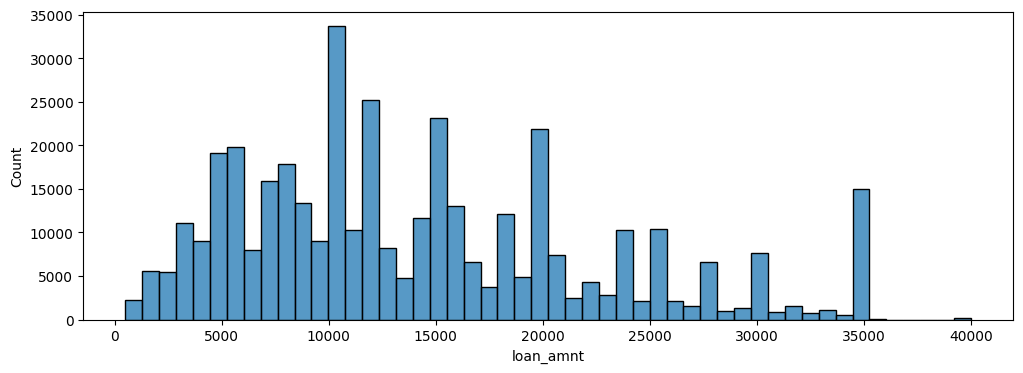

In [9]:
#since loan amt is continuous, we use histogram
plt.figure(figsize=(12,4))
sns.histplot(df["loan_amnt"],bins=50)

<Axes: >

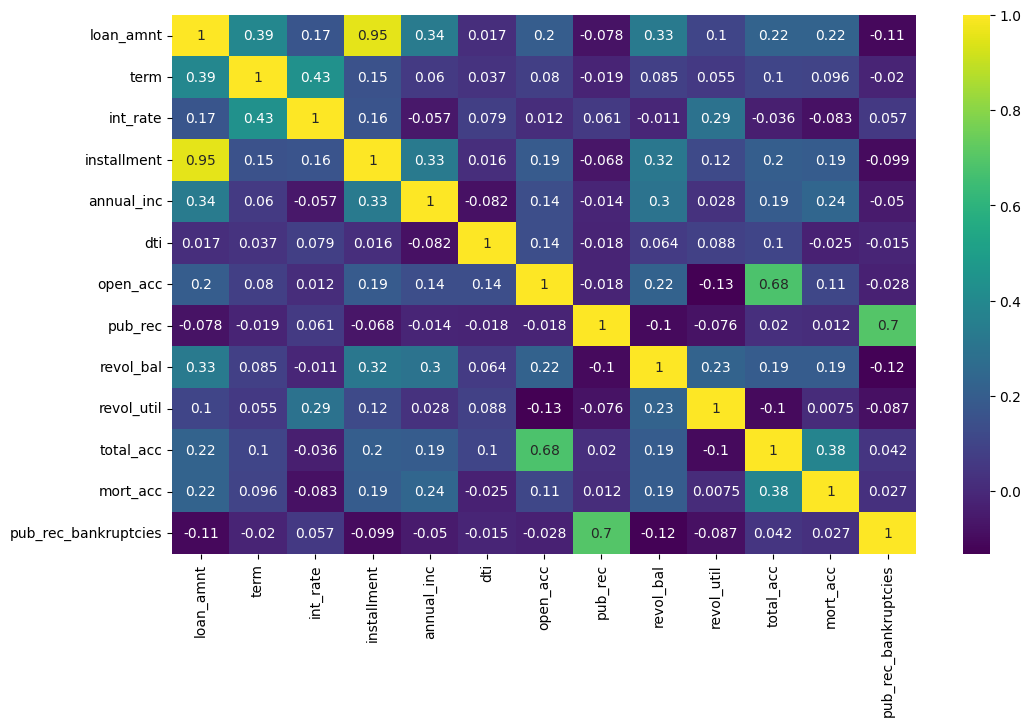

In [10]:
df['term'] = df['term'].apply(lambda term: int(term.split(' ')[1]))
plt.figure(figsize=(12,7))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='viridis')

<Axes: xlabel='installment', ylabel='loan_amnt'>

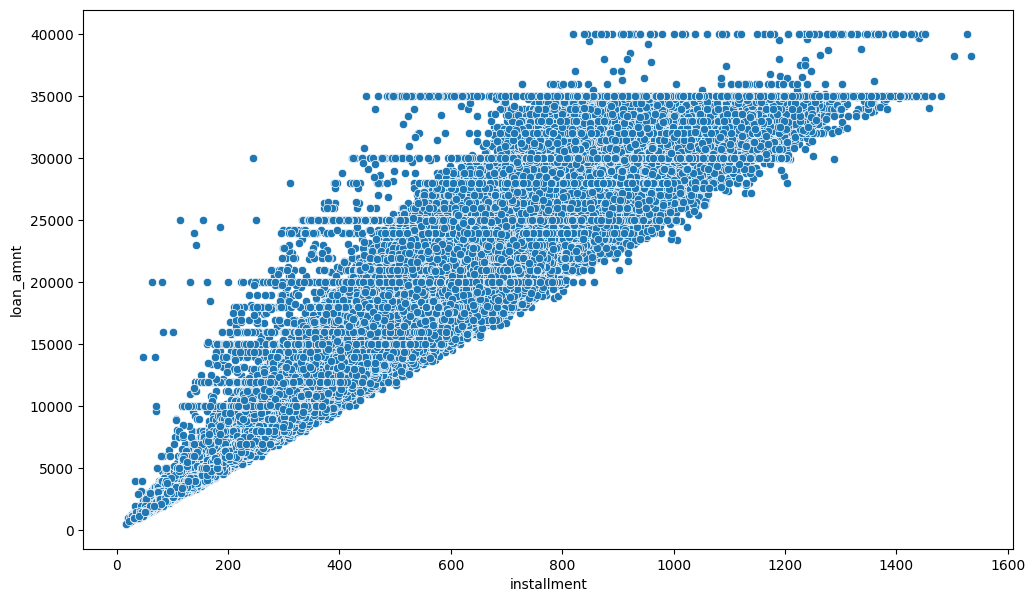

In [11]:
plt.figure(figsize=(12,7))
sns.scatterplot(x='installment',y='loan_amnt',data=df)

<Axes: xlabel='loan_status', ylabel='loan_amnt'>

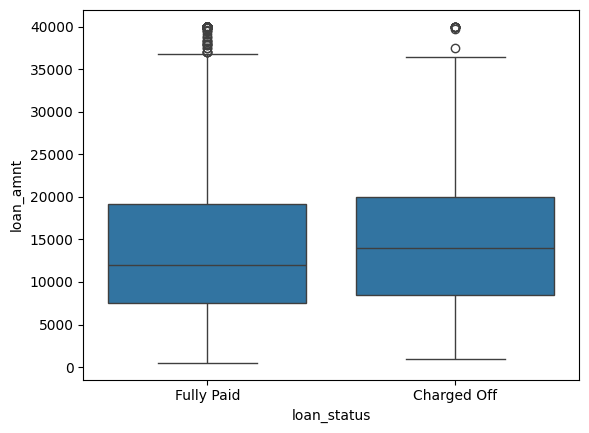

In [12]:
#for detection of any outliers
sns.boxplot(x='loan_status',y='loan_amnt',data=df)

In [13]:
df.groupby('loan_status')['loan_amnt'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,77673.0,15126.300967,8505.090557,1000.0,8525.0,14000.0,20000.0,40000.0
Fully Paid,318357.0,13866.878771,8302.319699,500.0,7500.0,12000.0,19225.0,40000.0


In [14]:
df['grade'].unique()

array(['B', 'A', 'C', 'E', 'D', 'F', 'G'], dtype=object)

<Axes: xlabel='grade', ylabel='count'>

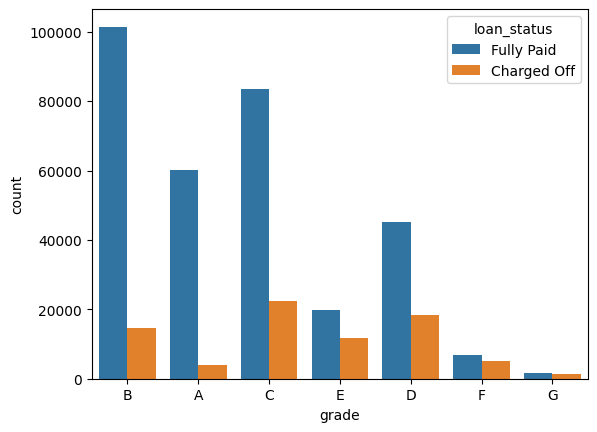

In [15]:
sns.countplot(x="grade",hue='loan_status',data=df)

In [16]:
df[df['grade']=='A'].groupby('loan_status')['grade'].count()*100/len(df[df['grade']=='A'])

,grade
loan_status,
Charged Off,6.287878
Fully Paid,93.712122


In [17]:
df['sub_grade'].unique()

array(['B4', 'B5', 'B3', 'A2', 'C5', 'C3', 'A1', 'B2', 'C1', 'A5', 'E4',
       'A4', 'A3', 'D1', 'C2', 'B1', 'D3', 'D5', 'D2', 'E1', 'E2', 'E5',
       'F4', 'E3', 'D4', 'G1', 'F5', 'G2', 'C4', 'F1', 'F3', 'G5', 'G4',
       'F2', 'G3'], dtype=object)

In [18]:
sub_order= sorted(df['sub_grade'].unique())

<Axes: xlabel='sub_grade', ylabel='count'>

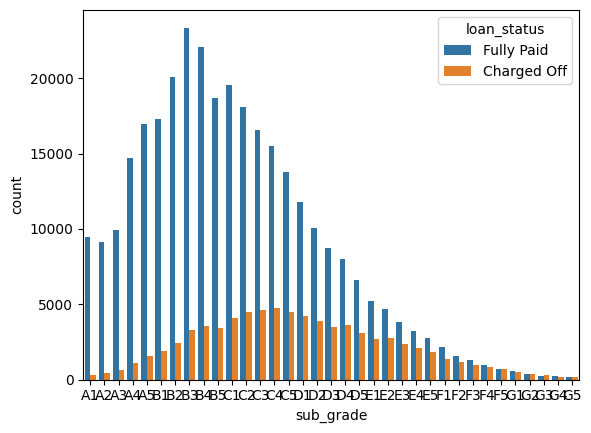

In [19]:
sns.countplot(x="sub_grade",hue='loan_status',order=sub_order,data=df)

<Axes: xlabel='emp_length', ylabel='count'>

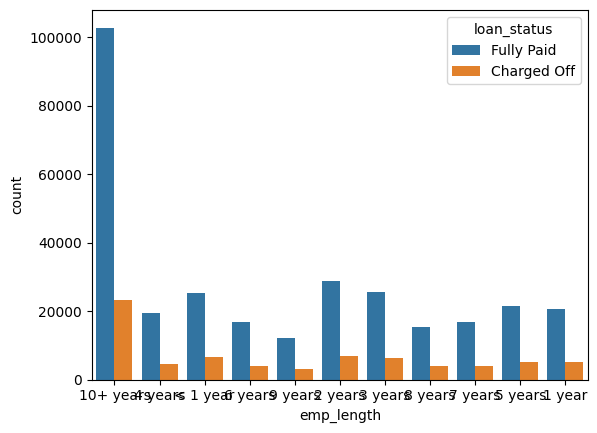

In [20]:
sns.countplot(x="emp_length",hue='loan_status',data=df)

<Axes: xlabel='verification_status', ylabel='count'>

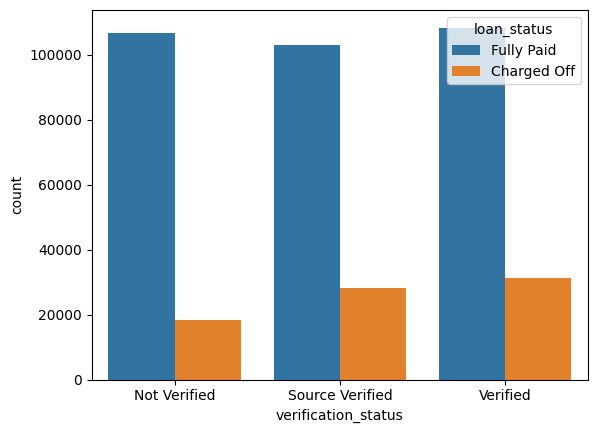

In [21]:
sns.countplot(x="verification_status",hue='loan_status',data=df)

In [22]:
df['loan_status']=df['loan_status'].apply(lambda x: 1 if x=='Fully Paid' else 0)

In [ ]:
df.corr()["loan_status"].sort_values().drop("loan_status").plot(kind="bar")

ValueError: could not convert string to float: 'B'

<Axes: xlabel='verification_status', ylabel='count'>

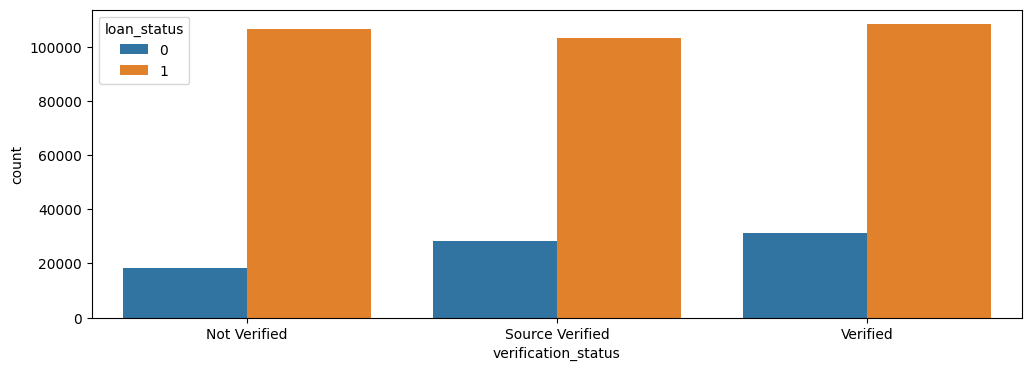

In [23]:
#verification status graph
plt.figure(figsize=(12,4))
sns.countplot(x="verification_status",data=df,hue="loan_status")

In [24]:
df['emp_title'].nunique()

173105

In [25]:
df.drop('emp_title',axis=1, inplace=True)

In [26]:
df.isnull().sum()*100/len(df)

,0
loan_amnt,0.000000
term,0.000000
int_rate,0.000000
installment,0.000000
grade,0.000000
sub_grade,0.000000
emp_length,4.621115
home_ownership,0.000000
annual_inc,0.000000
verification_status,0.000000


In [27]:
df['emp_length'].unique()

array(['10+ years', '4 years', '< 1 year', '6 years', '9 years',
       '2 years', '3 years', '8 years', '7 years', '5 years', '1 year',
       nan], dtype=object)

In [28]:
df.drop("emp_length", axis =1,inplace =True)

In [29]:
df['title'].nunique()

48816

In [30]:
df.drop('title',axis=1,inplace=True)

In [31]:
df['mort_acc']=df['mort_acc'].fillna(np.mean(df['mort_acc']))

In [32]:
df.isnull().sum()*100/len(df)

,0
loan_amnt,0.000000
term,0.000000
int_rate,0.000000
installment,0.000000
grade,0.000000
sub_grade,0.000000
home_ownership,0.000000
annual_inc,0.000000
verification_status,0.000000
issue_d,0.000000


In [33]:
df.dropna(inplace=True)

In [34]:
df.select_dtypes(['object']).columns.nunique()

10

In [35]:
df['term']

,term
0,36
1,36
2,36
3,36
4,60
...,...
396025,60
396026,36
396027,36
396028,60


In [36]:
df['term']=df["term"].apply(lambda x: int(str(x)[:3]))

In [37]:
df.drop("grade",axis=1,inplace=True)

In [38]:
dummies=pd.get_dummies(df["sub_grade"],drop_first=True)

In [39]:
df=pd.concat([df.drop("sub_grade",axis=1),dummies],axis=1)

In [40]:
df["home_ownership"].value_counts()

,count
home_ownership,
MORTGAGE,198022
RENT,159395
OWN,37660
OTHER,110
NONE,29
ANY,3


In [41]:
#replacing none and any with other
df["home_ownership"]=df["home_ownership"].replace(["NONE","ANY"],"OTHER")

In [42]:
df["Zip"]=df["address"].apply(lambda x:x[-5:])

In [43]:
df["Zip"].value_counts()

,count
Zip,
70466,56880
22690,56413
30723,56402
48052,55811
00813,45725
29597,45393
05113,45300
11650,11210
93700,11126


In [44]:
#converting into dummy variable
dummies=pd.get_dummies(df["Zip"],drop_first=True)

#concatinating with orginal data
df=pd.concat([df.drop("Zip",axis=1),dummies],axis=1)

In [45]:
df.drop("address",axis=1,inplace=True)

In [46]:
df.drop("issue_d",axis=1,inplace=True)

In [47]:
df["earliest_cr_line"]=df["earliest_cr_line"].apply(lambda x:int(x[-4:]))

In [48]:
df['pub_rec']=df['pub_rec'].apply(lambda x: 0 if x==0 else 1)

In [49]:
cols= df.select_dtypes(['object']).columns

In [50]:
def ordinal_mapper(data,var):

  ordinal_map = {k:i for i,k in enumerate(data[var].unique(),0)}
  data[var] = data[var].map(ordinal_map)

In [51]:
for var in cols:
  ordinal_mapper(df,var)

In [52]:
df[cols]

,home_ownership,verification_status,purpose,initial_list_status,application_type
0,0,0,0,0,0
1,1,0,1,1,0
2,0,1,2,1,0
3,0,0,2,1,0
4,1,2,2,1,0
...,...,...,...,...,...
396025,0,1,1,0,0
396026,1,1,1,1,0
396027,0,2,1,1,0
396028,1,2,1,1,0


In [53]:
data=df.sample(frac=.5,random_state=101)

In [54]:
from sklearn.model_selection import train_test_split

In [55]:
X=data.drop("loan_status",axis=1).values
y=data["loan_status"].values

#spliting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [56]:
from sklearn.preprocessing import MinMaxScaler

In [57]:
scaler=MinMaxScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [58]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)


In [59]:
print('NaNs in X_train:', np.isnan(X_train).sum())
print('Infinities in X_train:', np.isinf(X_train).sum())
print('NaNs in y_train:', np.isnan(y_train).sum())
print('Infinities in y_train:', np.isinf(y_train).sum())

NaNs in X_train: 0
Infinities in X_train: 0
NaNs in y_train: 0
Infinities in y_train: 0


In [60]:
#running model
#creating model
model = Sequential()

#adding layer
model.add(Dense(78,activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(39,activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(19,activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(19,activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(units=1,activation="sigmoid"))

model.compile(loss="binary_crossentropy",optimizer="adam")

#parameters for early stopping
early_stop=tf.keras.callbacks.EarlyStopping(monitor="val_loss",mode="min",verbose=1,patience=5)

In [61]:
#running the model
model.fit(x=X_train,y=y_train,epochs=25,batch_size=256,validation_data=(X_test,y_test),callbacks=[early_stop])

Epoch 1/25
618/618 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.3263 - val_loss: 0.2662
Epoch 2/25
618/618 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.2722 - val_loss: 0.2638
Epoch 3/25
618/618 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2678 - val_loss: 0.2629
Epoch 4/25
618/618 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2655 - val_loss: 0.2626
Epoch 5/25
618/618 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2645 - val_loss: 0.2613
Epoch 6/25
618/618 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.2638 - val_loss: 0.2622
Epoch 7/25
618/618 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2628 - val_loss: 0.2615
Epoch 8/25
618/618 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2617 - val_loss: 0.2614
Epoch 9/25
618/618 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2615 - val_loss: 0.2623
Epoch 10/25
618/618 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.2614 - val_loss: 0.2609
Epoch 11/25
618/618 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2608 - val_loss: 0.2608
Epoch 12/25
618/618 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

<Axes: >

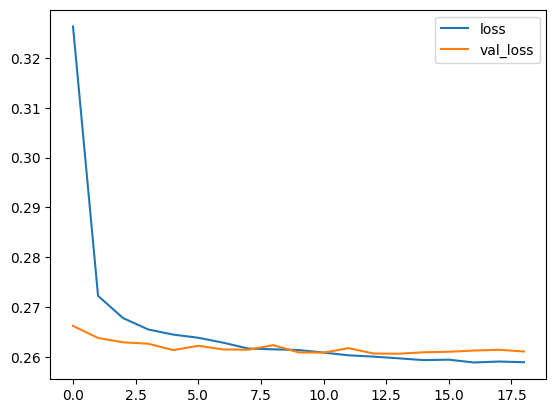

In [62]:
#plotting the losses
loss=pd.DataFrame(model.history.history)

loss.plot()

In [63]:
from sklearn.metrics import classification_report,confusion_matrix,roc_curve,roc_auc_score,auc

predict_proba=model.predict(X_test)
predict=(predict_proba > 0.5).astype("int32")
print(classification_report(y_test,predict))

1236/1236 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0       0.99      0.44      0.61      7947
           1       0.88      1.00      0.93     31575

    accuracy                           0.89     39522
   macro avg       0.93      0.72      0.77     39522
weighted avg       0.90      0.89      0.87     39522



In [64]:
# Assuming the classification report was printed by the previous cell, we can now display the confusion matrix
print("Confusion Matrix:")
pd.DataFrame(confusion_matrix(y_test,predict))

Confusion Matrix:


,0,1
0,3463,4484
1,35,31540


In [65]:
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       0.99      0.44      0.61      7947
           1       0.88      1.00      0.93     31575

    accuracy                           0.89     39522
   macro avg       0.93      0.72      0.77     39522
weighted avg       0.90      0.89      0.87     39522



In [66]:
pd.DataFrame(confusion_matrix(y_test,predict))

,0,1
0,3463,4484
1,35,31540


In [67]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

In [68]:
clf=[LinearSVC(),
     LogisticRegression(random_state=0,solver='lbfgs',max_iter=1000),
     GaussianNB(),
     RandomForestClassifier(random_state=0,n_estimators=10)]

In [69]:
def model_clf(x):
    cl=x
    cl.fit(X_train,y_train)
    predict=cl.predict(X_test)
    print(classification_report(y_test,predict))

In [70]:
for x in clf:
    model_clf(x)

              precision    recall  f1-score   support

           0       0.98      0.44      0.61      7947
           1       0.88      1.00      0.93     31575

    accuracy                           0.89     39522
   macro avg       0.93      0.72      0.77     39522
weighted avg       0.90      0.89      0.87     39522

              precision    recall  f1-score   support

           0       0.96      0.45      0.62      7947
           1       0.88      1.00      0.93     31575

    accuracy                           0.89     39522
   macro avg       0.92      0.73      0.78     39522
weighted avg       0.90      0.89      0.87     39522

              precision    recall  f1-score   support

           0       0.71      0.56      0.63      7947
           1       0.90      0.94      0.92     31575

    accuracy                           0.87     39522
   macro avg       0.80      0.75      0.77     39522
weighted avg       0.86      0.87      0.86     39522

              preci

In [81]:
from sklearn.utils import shuffle

#creating function which samples equal classes
def sampling_k_elements(group, k=77000):
    if len(group) < k:
        return group
    return group.sample(k)

data = df.groupby('loan_status', group_keys=False).apply(sampling_k_elements).reset_index(drop=True)
data=shuffle(data)

/tmp/ipykernel_659/3443454593.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = df.groupby('loan_status', group_keys=False).apply(sampling_k_elements).reset_index(drop=True)


In [96]:
#dividing data into feature and target
X=data.drop("loan_status",axis=1).values
y=data["loan_status"].values

#spliting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

#scaling the data
#scaling the data
scaler=MinMaxScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [97]:
model.fit(x=X_train,y=y_train,epochs=25,batch_size=256,validation_data=(X_test,y_test),callbacks=[early_stop])

Epoch 1/25
482/482 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3524 - val_loss: 0.3584
Epoch 2/25
482/482 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3522 - val_loss: 0.3586
Epoch 3/25
482/482 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3521 - val_loss: 0.3588
Epoch 4/25
482/482 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3526 - val_loss: 0.3582
Epoch 5/25
482/482 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3519 - val_loss: 0.3586
Epoch 5: early stopping


<Axes: >

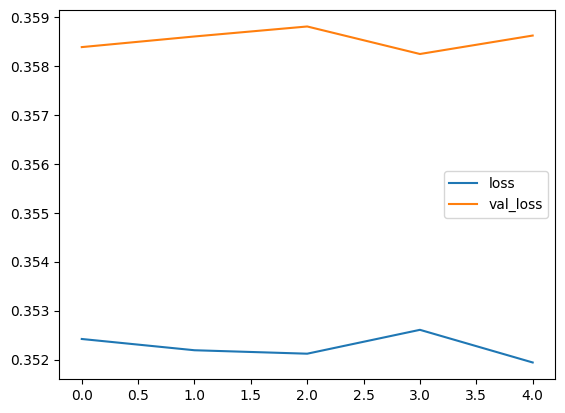

In [98]:
loss=pd.DataFrame(model.history.history)

loss.plot()

In [88]:
predict_proba = model.predict(X_test)
predict=(predict_proba > 0.5).astype("int32")
print(classification_report(y_test,predict))

963/963 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0       0.79      0.83      0.81     15398
           1       0.82      0.77      0.80     15402

    accuracy                           0.80     30800
   macro avg       0.80      0.80      0.80     30800
weighted avg       0.80      0.80      0.80     30800



In [89]:
for x in clf:
    model_clf(x)

              precision    recall  f1-score   support

           0       0.79      0.82      0.80     15398
           1       0.81      0.78      0.80     15402

    accuracy                           0.80     30800
   macro avg       0.80      0.80      0.80     30800
weighted avg       0.80      0.80      0.80     30800

              precision    recall  f1-score   support

           0       0.79      0.81      0.80     15398
           1       0.81      0.78      0.79     15402

    accuracy                           0.80     30800
   macro avg       0.80      0.80      0.80     30800
weighted avg       0.80      0.80      0.80     30800

              precision    recall  f1-score   support

           0       0.91      0.55      0.69     15398
           1       0.68      0.95      0.79     15402

    accuracy                           0.75     30800
   macro avg       0.79      0.75      0.74     30800
weighted avg       0.79      0.75      0.74     30800

              preci